**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 5**
Preprocesamiento de datos

---

*   NOMBRE: JOSÉ FLORENCIO MAGUEY PERALTA
*   MATRÍCULA: A01796727

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia de datos/Módulo 5"
os.chdir(DIR)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
response_df = pd.read_csv('responses.csv')
response_df

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
0,5.0,3.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,1.0,...,20.0,163.0,48.0,1.0,female,right handed,college/bachelor degree,no,village,block of flats
1,4.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,...,19.0,163.0,58.0,2.0,female,right handed,college/bachelor degree,no,city,block of flats
2,5.0,5.0,2.0,2.0,3.0,4.0,5.0,3.0,5.0,3.0,...,20.0,176.0,67.0,2.0,female,right handed,secondary school,no,city,block of flats
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,22.0,172.0,59.0,1.0,female,right handed,college/bachelor degree,yes,city,house/bungalow
4,5.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,3.0,1.0,...,20.0,170.0,59.0,1.0,female,right handed,secondary school,no,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,5.0,2.0,5.0,2.0,2.0,5.0,4.0,4.0,4.0,3.0,...,20.0,164.0,57.0,1.0,female,right handed,secondary school,no,city,house/bungalow
1006,4.0,4.0,5.0,1.0,3.0,4.0,1.0,4.0,1.0,1.0,...,27.0,183.0,80.0,5.0,male,left handed,masters degree,no,village,house/bungalow
1007,4.0,3.0,1.0,1.0,2.0,2.0,2.0,3.0,4.0,1.0,...,18.0,173.0,75.0,0.0,female,right handed,secondary school,yes,city,block of flats
1008,5.0,3.0,3.0,3.0,1.0,3.0,1.0,3.0,4.0,1.0,...,25.0,173.0,58.0,1.0,female,right handed,college/bachelor degree,no,city,block of flats


1. Determina cuántas variables numéricas y cuántas de texto posee el conjunto de datos con el método `info()` y utiliza el método `describe()` del dataframe, para obtener el resumen de las estadísticas descriptivas. Separa el análisis según el tipo de datos (number, object).

In [6]:
# Se hace una lista de variables numéricas y otra de categóricas
num_cols = response_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = response_df.select_dtypes(exclude=np.number).columns.tolist()

In [7]:
response_df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Smoking                 1002 non-null   object
 1   Alcohol                 1005 non-null   object
 2   Punctuality             1008 non-null   object
 3   Lying                   1008 non-null   object
 4   Internet usage          1010 non-null   object
 5   Gender                  1004 non-null   object
 6   Left - right handed     1007 non-null   object
 7   Education               1009 non-null   object
 8   Only child              1008 non-null   object
 9   Village - town          1006 non-null   object
 10  House - block of flats  1006 non-null   object
dtypes: object(11)
memory usage: 86.9+ KB


In [8]:
response_df[cat_cols].describe().T

,count,unique,top,freq
Smoking,1002,4,tried smoking,430
Alcohol,1005,3,social drinker,659
Punctuality,1008,3,i am always on time,399
Lying,1008,4,sometimes,549
Internet usage,1010,4,few hours a day,744
Gender,1004,2,female,593
Left - right handed,1007,2,right handed,906
Education,1009,6,secondary school,621
Only child,1008,2,no,754
Village - town,1006,2,city,707


In [9]:
response_df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Columns: 139 entries, Music to Number of siblings
dtypes: float64(134), int64(5)
memory usage: 1.1 MB


In [10]:
response_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Music,1007.0,4.731877,0.664049,1.0,5.0,5.0,5.0,5.0
Slow songs or fast songs,1008.0,3.328373,0.833931,1.0,3.0,3.0,4.0,5.0
Dance,1006.0,3.113320,1.170568,1.0,2.0,3.0,4.0,5.0
Folk,1005.0,2.288557,1.138916,1.0,1.0,2.0,3.0,5.0
Country,1005.0,2.123383,1.076136,1.0,1.0,2.0,3.0,5.0
...,...,...,...,...,...,...,...,...
Spending on healthy eating,1008.0,3.557540,1.093750,1.0,3.0,4.0,4.0,5.0
Age,1003.0,20.433699,2.828840,15.0,19.0,20.0,22.0,30.0
Height,990.0,173.514141,10.024505,62.0,167.0,173.0,180.0,203.0
Weight,990.0,66.405051,13.839561,41.0,55.0,64.0,75.0,165.0


2. Clasifique la variable `Weight` según su escala de medición. En función de ello elija el gráfico a generar (histograma / barras) y fundamente su elección.


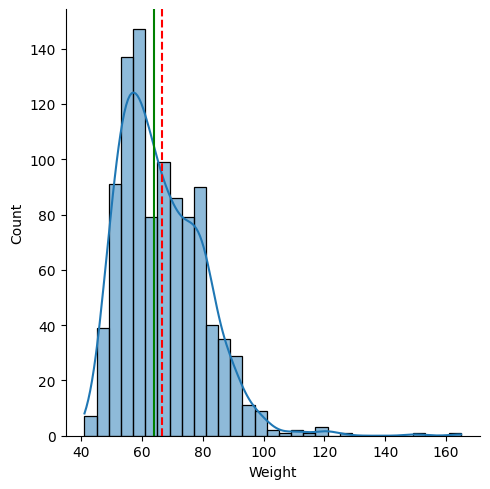

In [11]:
#sns.histplot(response_df['Weight'])

sns.displot(data=response_df, x='Weight', kde=True)
plt.axvline(response_df['Weight'].mean(), color='r', linestyle='--')
plt.axvline(response_df['Weight'].median(), color='g', linestyle='-')

Considero que el histograma nos permite visaluzar la distribución de los datos, de acuerdo con el módulo anterior, observamos que tiene un sesgo postivo y la curotsis es leptocurtica.
Aunado a lo anterior, la gráfica de barras no nos permite distinguir bien las frecuencias de las magnitudes presentadas en el CSV.

3. Clasifique la distribución del peso según su asimetría, justificando tu respuesta. Incluye el cálculo numérico que lo demuestra.

In [134]:
response_df['Weight'].skew(numeric_only=True)

1.2359870768359555

Como podemos observar en el gráfico, el histrograma tiene un sesgo positivo, esto debido a que la cola de la derecha es más larga que la de la izquierda. El valor de la asimetría resulta supero a 1, lo cual confirmaría el sesgo que presenta el histograma. Por último, podemos observar que la curva de la campaza es leptocúrtica.

4. ¿Cuántos valores faltantes tiene la variable `Weight`? ¿Qué porcentaje representa?


In [12]:
response_df['Weight'].isna().sum()

20

In [13]:
response_df['Weight'].isna().mean() * 100

1.9801980198019802

5. ¿Tendrán los valores faltantes de `Weight` relación con alguna otra variable? Analízalo considerando las siguientes columnas:
*   Numéricas: `Age, Number of siblings`
*   Categóricas: `Gender, Education`

Para ello deberás dividir cada columna en dos grupos: con/sin faltantes en `Weight` y utilizar métodos gráficos y la prueba t para ver si hay diferencias significativas. NO olvides incluir las conclusiones del análisis con los resultados obtenidos.

**NOTA**. Puedes reutilizar las funciones `Diagnose_MV_Numerical` y `Diagnose_MV_Categorical` definidas en Hands-On-Prep_Missing_Values.zip. Revisa nuevamente cómo utilizarlas.

In [14]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    labels=[]
    box_sr = pd.Series('',index = BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10,4))

    att_range = (df[str_att_name].min(),df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data,group_2_data).pvalue

    print('p-value of t-test: {}'.format(p_value))

In [15]:
from scipy.stats import chi2_contingency
def Diagnose_MV_Categorical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    plt.figure(figsize=(10,4))
    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()

    contigency_table = pd.crosstab(BM_MV,df[str_att_name])
    p_value = chi2_contingency(contigency_table)[1]

    print('p-value of Chi_squared test: {}'.format(p_value))

Diagnosis Analysis of Missing Values for Age:


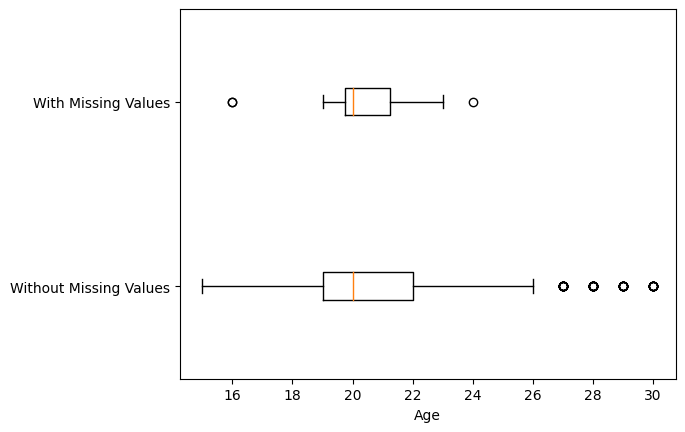

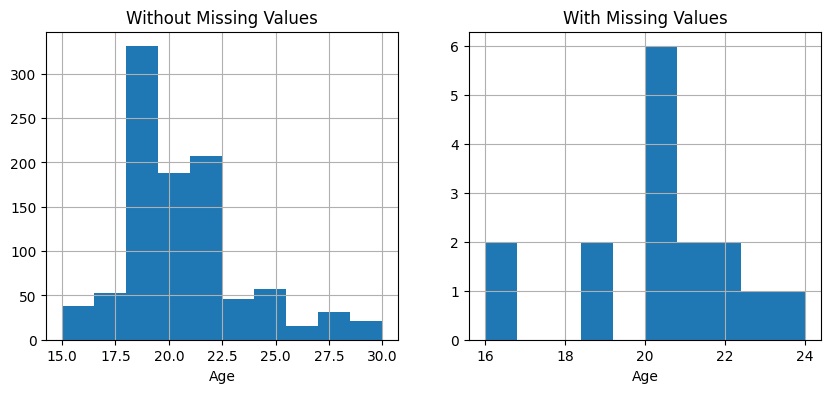

p-value of t-test: 0.7258243979822129
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Number of siblings:


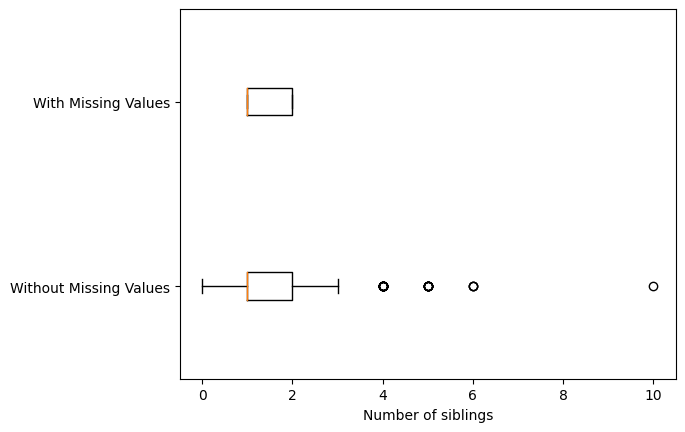

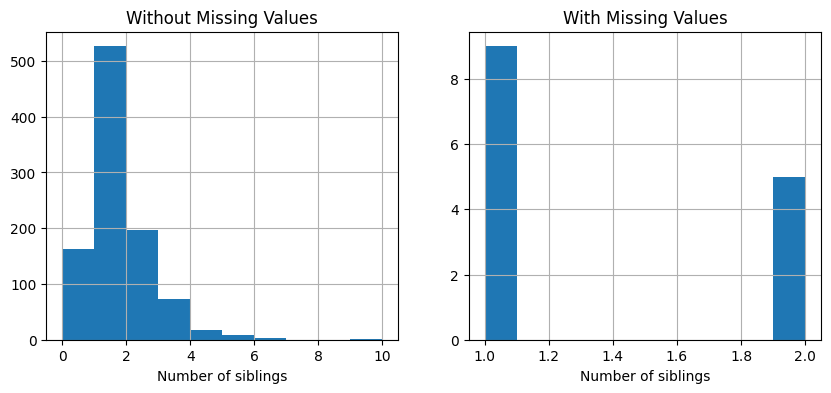

p-value of t-test: 0.8255092107556896
- - - - - - - - - - - - divider - - - - - - - - - - - 


In [16]:
numerical_attributes = ['Age', 'Number of siblings']

BM_MV = response_df['Weight'].isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(response_df,att,BM_MV)
    print('- - - - - - - - - - - - divider - - - - - - - - - - - ')

Resultados para ***AGE***:
Los datos faltantes son del tipo MNAR, pues la población entrevistada no revela el peso debido a su edad. La información que se presenta en el boxplot presentamos outliers que mueven el promedio, los histogramas no son uniformes en su forma, y el valor t-test es menor al 95%.

Resultados para ***Number of sibilings***:
Los datos faltantes son del tipo MNAR, pues la población entrevistada no revela el peso para aquellos que tienen 1 o dos hermanos. El boxplot para la población que ha decidido no revelar su peso es muy pequeño, por lo cual porvoca que la muestra sea insuficiente pues son aproximadamente 13 datos. Para los histogramas observamos que sus formas no son similares, lo cual altera la inforamción recabada. Por último, la prueba del t-test resulta menor al 95%.

Diagnosis Analysis of Missing Values for Gender:


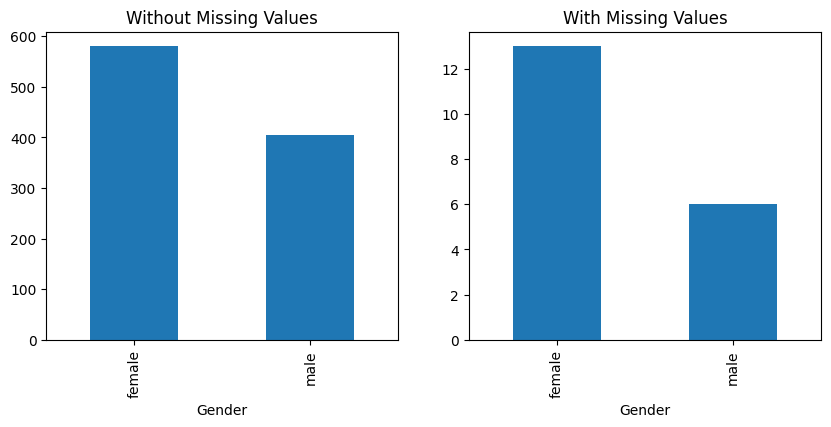

p-value of Chi_squared test: 0.5472167199163878
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Education:


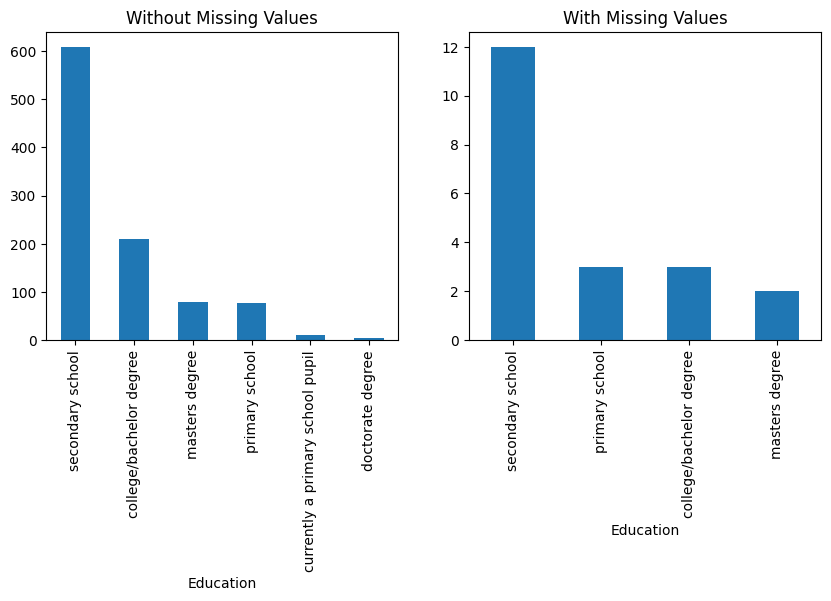

p-value of Chi_squared test: 0.8424822989541867
- - - - - - - - - - - - divider - - - - - - - - - - - 


In [17]:
categorical_attributes = ['Gender', 'Education']

BM_MV = response_df.Weight.isna()
for att in categorical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Categorical(response_df,att,BM_MV)
    print('- - - - - - - - - - - - divider - - - - - - - - - - - ')

Resultados para ***Gender***:
MCAR porque la probabilidad es casi igual para ambos, y los gráficos demuestran lo mismo. Es más probable que las mujeres no den su peso que los hombres.

Resultados para ***Education***:
MAR debido a que no detecto que exista una relación entre el dato del peso y del nivel educativo.

6. Utiliza una medida de tendencia central para imputar los valores faltantes de `Weight`. ¿Cuál es recomendable y por qué?

In [30]:
df_im= response_df
df_im.fillna(df_im.Weight.mean(), inplace=True)

Se imputan datos utlizando la media debido a que no son muchos los datos faltantes; de acuerdo con los datos obtenidos en la pregunta 4, los faltantes equivalen al 1.98%.

7. ¿Hay valores atípicos de la variable `Weight`? Confírmalo con un gráfico de boxplot. ¿Cuántos son? Almacénalos en un dataframe independiente y elimínalos del conjunto original.

<Axes: xlabel='Weight'>

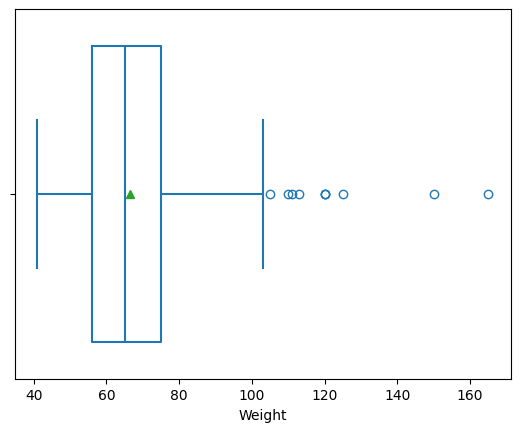

In [31]:
sns.boxplot(x=df_im['Weight'], showmeans=True, fill=False)

In [32]:
#conteo de outliers
bm_out=df_im[df_im['Weight']>105]
bm_out

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
292,5.0,4.0,5.0,2.0,3.0,2.0,5.0,5.0,4.0,1.0,...,21.0,184.000000,120.0,1.0,female,right handed,secondary school,no,city,house/bungalow
612,5.0,3.0,5.0,1.0,1.0,3.0,2.0,3.0,4.0,3.0,...,23.0,172.000000,110.0,2.0,male,right handed,secondary school,no,village,block of flats
715,4.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,5.0,5.0,...,29.0,183.000000,111.0,1.0,male,left handed,secondary school,no,village,house/bungalow
793,2.0,3.0,3.0,1.0,2.0,3.0,3.0,3.0,2.0,4.0,...,24.0,185.000000,120.0,2.0,male,right handed,doctorate degree,no,city,house/bungalow
796,3.0,5.0,3.0,2.0,2.0,4.0,3.0,5.0,1.0,4.0,...,27.0,189.000000,113.0,3.0,male,left handed,doctorate degree,no,city,house/bungalow
859,5.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,3.0,2.0,...,20.0,190.000000,125.0,1.0,male,right handed,secondary school,no,city,block of flats
885,3.0,4.0,3.0,2.0,2.0,2.0,3.0,4.0,4.0,4.0,...,23.0,66.405051,165.0,0.0,female,right handed,secondary school,yes,city,house/bungalow
973,5.0,3.0,2.0,5.0,5.0,4.0,5.0,2.0,5.0,5.0,...,20.0,175.000000,120.0,2.0,female,right handed,secondary school,no,city,block of flats
992,4.0,4.0,4.0,1.0,4.0,4.0,1.0,3.0,4.0,4.0,...,30.0,200.000000,150.0,1.0,male,right handed,masters degree,no,city,block of flats


<Axes: xlabel='Weight'>

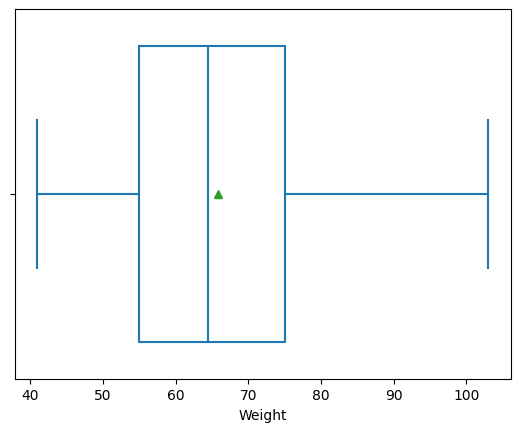

In [33]:
#todos los outliers están a la derecha del bigote
upcap= df_im.Weight.quantile(0.75) + (1.5*(df_im.Weight.quantile(0.75)-df_im.Weight.quantile(0.25)))
df_im=df_im[df_im['Weight']<upcap]#se filtra el bigote
sns.boxplot(x=df_im['Weight'], showmeans=True, fill=False)

8. Repite el mismo proceso de valores atípicos con la variable `Height`.

<Axes: xlabel='Height'>

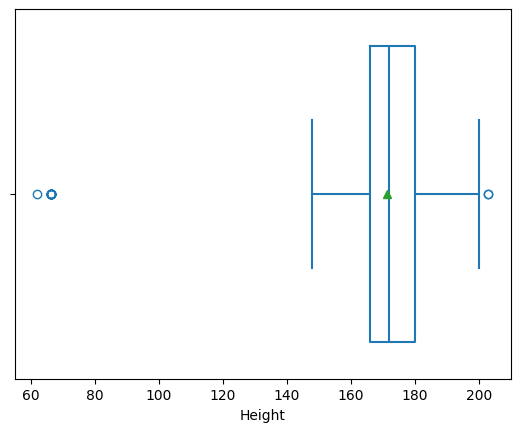

In [120]:
sns.boxplot(x=df_im['Height'], showmeans=True, fill=False)

In [121]:
#validamos que no tengamos valores en blanco o nulos, así sé si tengo que imputar
df_im['Height'].isna().sum()

0

<Axes: xlabel='Height'>

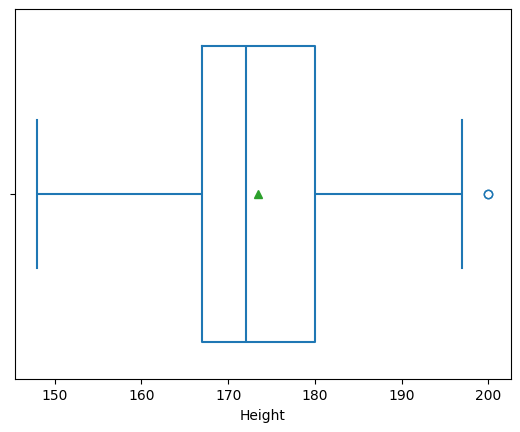

In [123]:
df_height = df_im
#       Q3                               |----------------------------------IQR-----------------------------|
ucap= df_height.Height.quantile(0.75) + (1.5*(df_height.Height.quantile(0.75)-df_height.Height.quantile(0.25)))
lcap= df_height.Height.quantile(0.25) - (1.5*(df_height.Height.quantile(0.75)-df_height.Height.quantile(0.25)))
BM_lcap=df_height.Height<lcap
BM_ucap=df_height.Height>ucap
df_height = df_height[~BM_lcap & ~BM_ucap]
sns.boxplot(x=df_height['Height'], showmeans=True, fill=False)

9. ¿Hay encuestados que sean atípicos según su índice de masa corporal (`BMI`)? El `BMI` puede ser calculado usando la siguiente fórmula:

`BMI = Weight / Height ^ 2`

**NOTA**. El peso tiene que estar en kilogramos y la altura en metros, pero en el conjunto la altura se ha registrado en centímetros, por lo que deberás convertirla a metros.

In [124]:
df_BMI=df_height
df_BMI['BMI']=df_BMI['Weight']/(df_BMI['Height']/100)**2
df_BMI

<ipython-input-124-79baac7c4a4d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_BMI['BMI']=df_BMI['Weight']/(df_BMI['Height']/100)**2


,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats,BMI
0,5.0,3.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,1.0,...,163.0,48.0,1.0,female,right handed,college/bachelor degree,no,village,block of flats,18.066167
1,4.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,...,163.0,58.0,2.0,female,right handed,college/bachelor degree,no,city,block of flats,21.829952
2,5.0,5.0,2.0,2.0,3.0,4.0,5.0,3.0,5.0,3.0,...,176.0,67.0,2.0,female,right handed,secondary school,no,city,block of flats,21.629649
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,172.0,59.0,1.0,female,right handed,college/bachelor degree,yes,city,house/bungalow,19.943213
4,5.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,3.0,1.0,...,170.0,59.0,1.0,female,right handed,secondary school,no,village,house/bungalow,20.415225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,5.0,2.0,5.0,2.0,2.0,5.0,4.0,4.0,4.0,3.0,...,164.0,57.0,1.0,female,right handed,secondary school,no,city,house/bungalow,21.192742
1006,4.0,4.0,5.0,1.0,3.0,4.0,1.0,4.0,1.0,1.0,...,183.0,80.0,5.0,male,left handed,masters degree,no,village,house/bungalow,23.888441
1007,4.0,3.0,1.0,1.0,2.0,2.0,2.0,3.0,4.0,1.0,...,173.0,75.0,0.0,female,right handed,secondary school,yes,city,block of flats,25.059307
1008,5.0,3.0,3.0,3.0,1.0,3.0,1.0,3.0,4.0,1.0,...,173.0,58.0,1.0,female,right handed,college/bachelor degree,no,city,block of flats,19.379197


In [125]:
cat_cols = df_BMI.select_dtypes(exclude=np.number).columns.tolist()
#validamos que las columnas no contengan datos que no hagan match con el tipo de dato
for col in df_BMI[cat_cols]:
 print('-----------'+col+'-----------')
 dft=df_BMI[col].value_counts()
 print(dft)

-----------Smoking-----------
Smoking
tried smoking     421
never smoked      194
current smoker    184
former smoker     171
66.405051           8
Name: count, dtype: int64
-----------Alcohol-----------
Alcohol
social drinker    641
drink a lot       219
never             113
66.405051           5
Name: count, dtype: int64
-----------Punctuality-----------
Punctuality
i am always on time        389
i am often early           313
i am often running late    274
66.405051                    2
Name: count, dtype: int64
-----------Lying-----------
Lying
sometimes                        530
only to avoid hurting someone    261
everytime it suits me            135
never                             50
66.405051                          2
Name: count, dtype: int64
-----------Internet usage-----------
Internet usage
few hours a day            723
less than an hour a day    135
most of the day            117
no time at all               3
Name: count, dtype: int64
-----------Gender-----------
Ge

In [126]:
#se elimnan del dtaframe todas las filas que contienen un 66
for col in df_BMI[cat_cols]:
    df_BMI = df_BMI[~df_BMI[col].astype(str).str.contains("66")]

#validamos que las columnas no contengan datos que no hagan match con el tipo de dato
for col in df_BMI[cat_cols]:
 print('-----------'+col+'-----------')
 dft=df_BMI[col].value_counts()
 print(dft)

-----------Smoking-----------
Smoking
tried smoking     409
never smoked      191
current smoker    177
former smoker     168
Name: count, dtype: int64
-----------Alcohol-----------
Alcohol
social drinker    624
drink a lot       210
never             111
Name: count, dtype: int64
-----------Punctuality-----------
Punctuality
i am always on time        377
i am often early           304
i am often running late    264
Name: count, dtype: int64
-----------Lying-----------
Lying
sometimes                        513
only to avoid hurting someone    253
everytime it suits me            132
never                             47
Name: count, dtype: int64
-----------Internet usage-----------
Internet usage
few hours a day            700
less than an hour a day    131
most of the day            111
no time at all               3
Name: count, dtype: int64
-----------Gender-----------
Gender
female    562
male      383
Name: count, dtype: int64
-----------Left - right handed-----------
Left - righ

10. Utiliza boxplots para visualizar la distribución del `BMI` según cada una de las variables categóricas de texto. Comenta un hallazgo que llame tu atención.

**Smoker**: el IMC dentro de los rangos que van desde insuficiente ponderal hasta sobrepeso. Los promedios están dentro de un intervalo normal (18.5-24.9). Para los que tienen obesidad (outliers), son los que nunca han fumado, intentaron fumar, y fumadores.

**Alcohol**: el IMC dentro de los rangos que van desde insuficiente ponderal hasta obesidad. Los promedios están dentro de un intervalo normal (18.5-24.9). Todas las categorías presentan obesidad; sin embargo, los outliers sólo estánpresente en los bebedres sociales y los que beben demasiado. De manera personal, resulta interesante el comportamiento de los que no toman, pues si bien, no presentan outliers, podemos observar que existen casos con obesidad por los bigotes.

**Punctuality**: Los que siempre van tarde, presetan casos de sobrepeso (outliers), pero no alarmantes y la media se encuentra en intervalos normales. Para los otros dos casos, presentan obesidad (outliers).

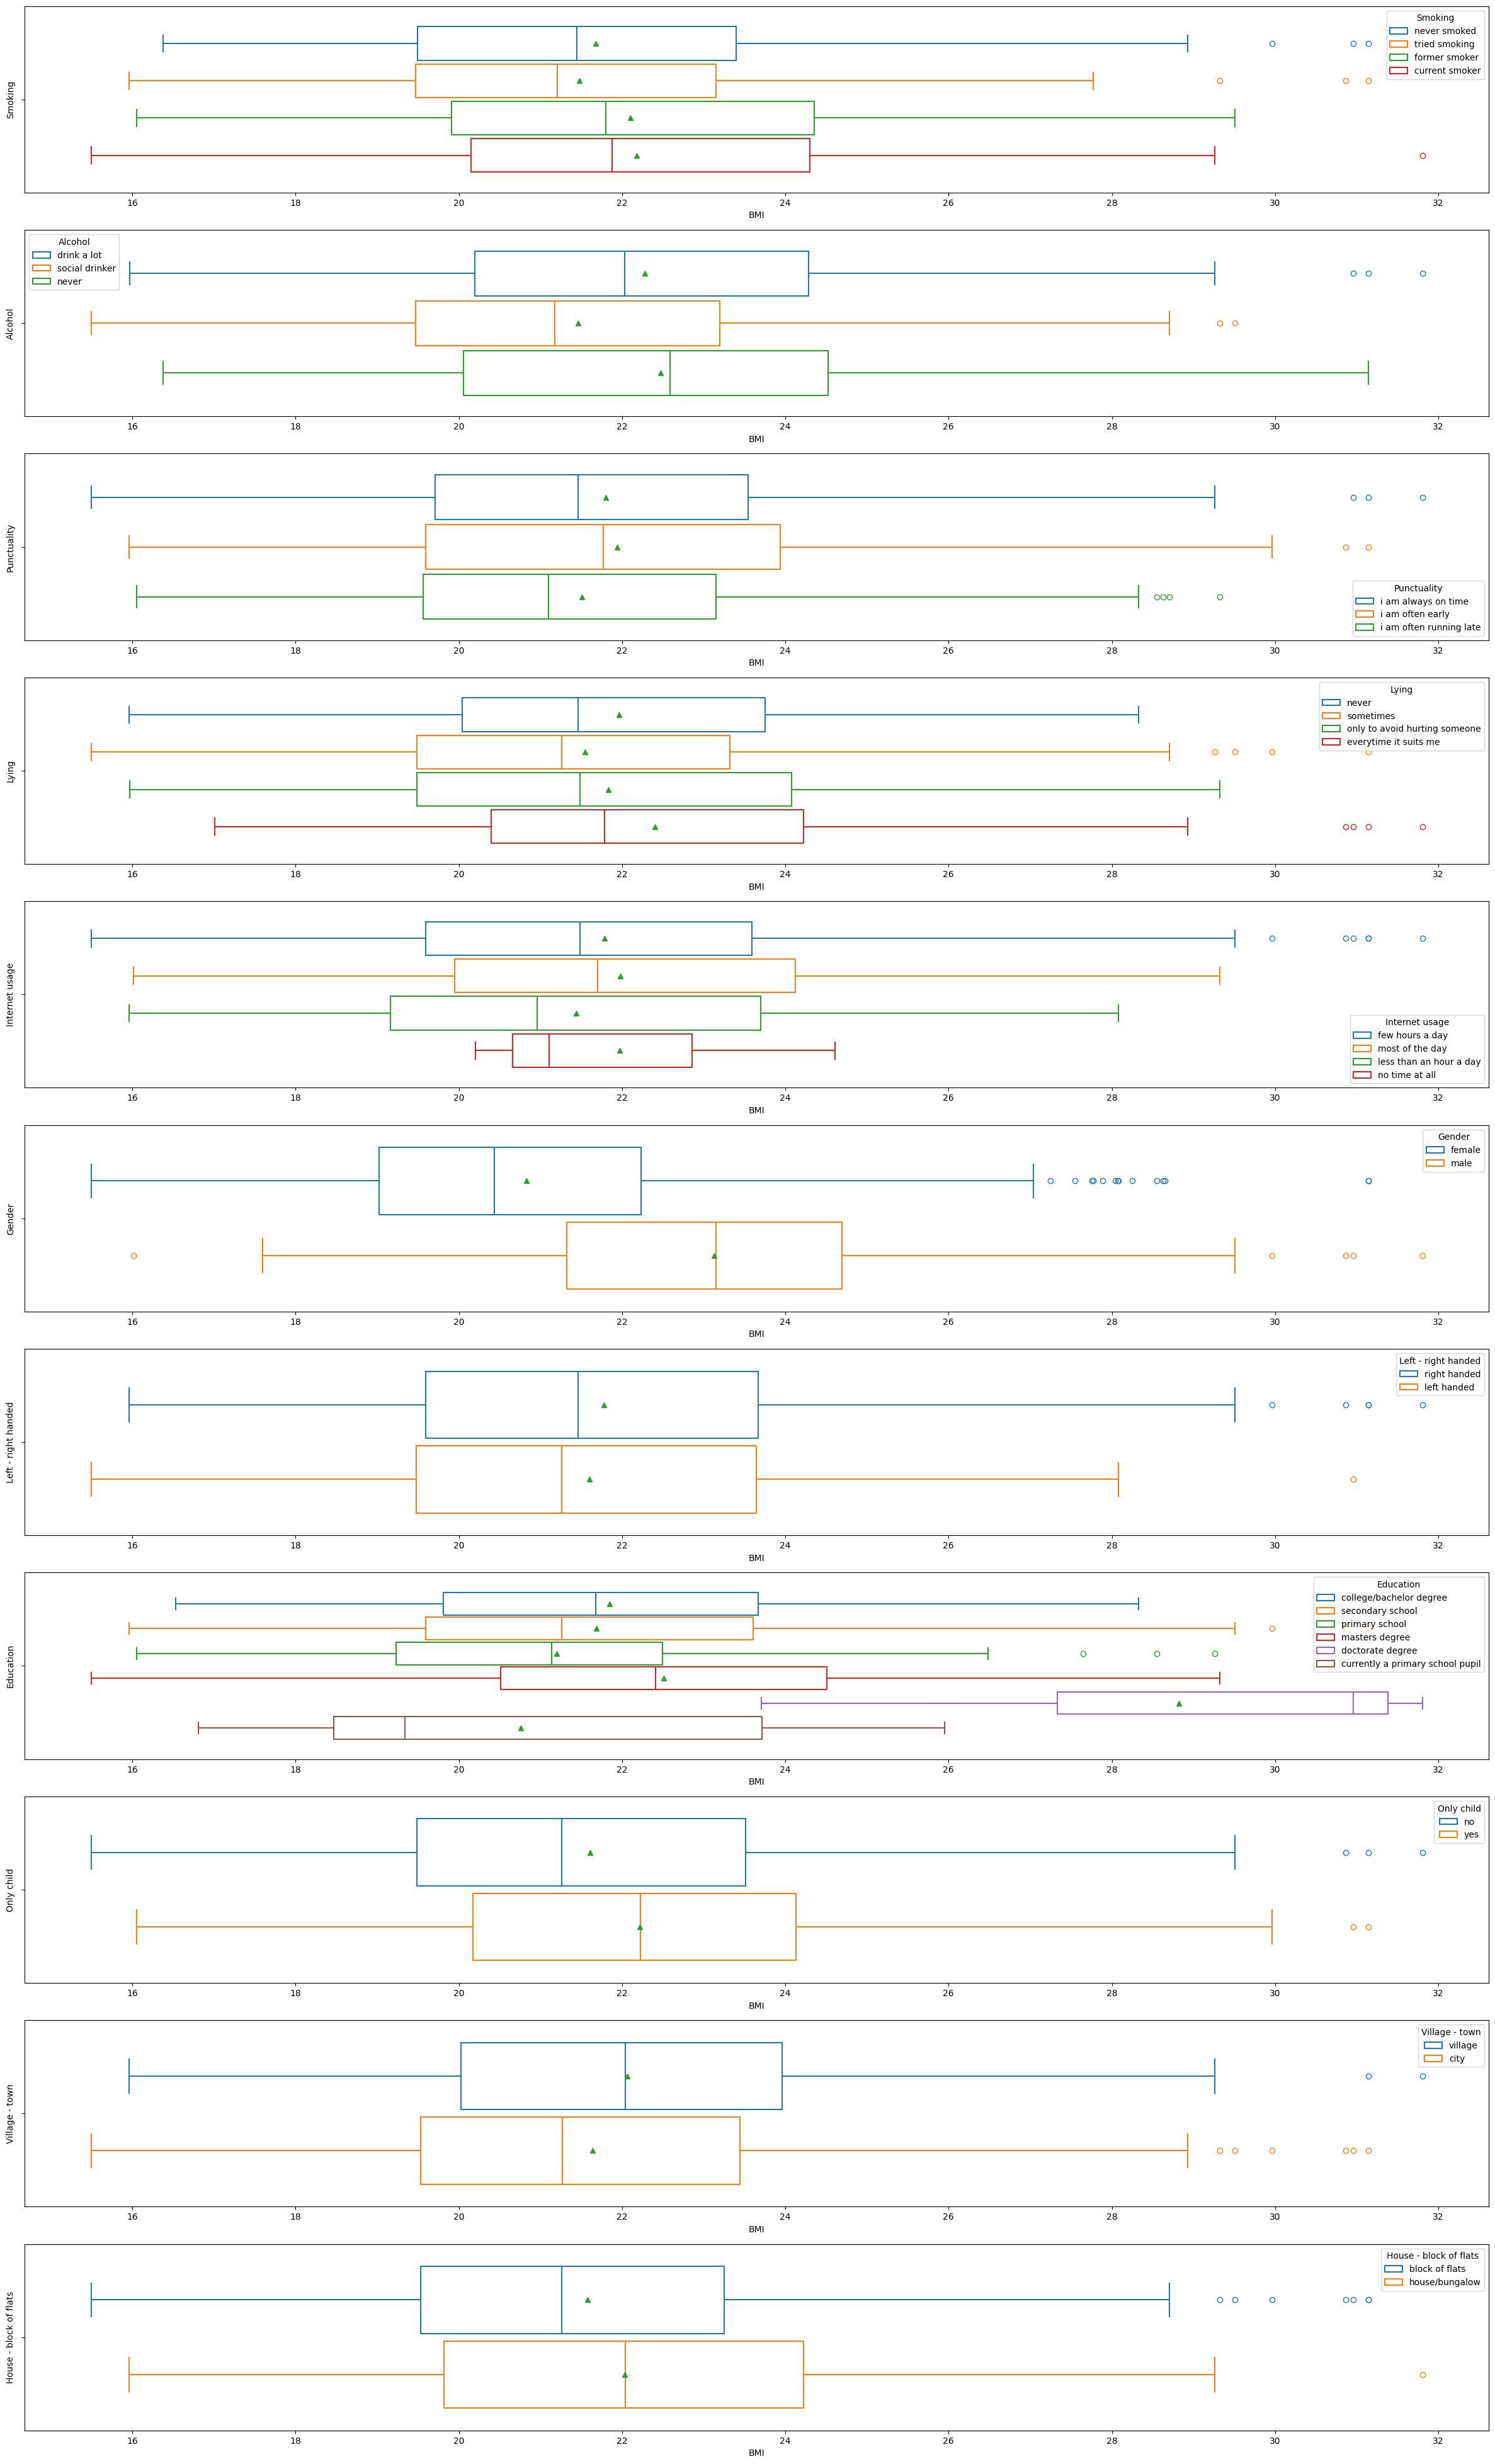

In [131]:
#sns.boxplot(data=df_BMI, x="Gender", y="BMI")

fig, axes = plt.subplots(11,1, figsize=(30,50))
axes = axes.ravel()

for col, ax in zip(df_BMI[cat_cols], axes):
    sns.boxplot(data=df_BMI, x='BMI', ax=ax, showmeans=True, hue=col, gap=.1, fill=False)
    ax.set(ylabel=f'{col}')
